In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
df = pd.read_csv(r"C:\Users\good2\Desktop\sales.csv")

In [3]:
df = df.rename(columns={
    "InvoiceDate": "ds",
    "Profit": "y"
})

In [4]:
df["ds"] = pd.to_datetime(df["ds"])

In [5]:
model = Prophet()
model.fit(df)

18:04:54 - cmdstanpy - INFO - Chain [1] start processing
18:05:10 - cmdstanpy - INFO - Chain [1] done processing


In [6]:
future = model.make_future_dataframe(periods=30)
forecast = model.predict(future)

In [7]:
forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail(30)

,ds,yhat,yhat_lower,yhat_upper
2298,2010-01-30 12:35:00,0.494743,-74.398721,79.641975
2299,2010-01-31 12:35:00,1.222367,-77.890784,78.663358
2300,2010-02-01 12:35:00,4.941433,-75.680727,88.603382
2301,2010-02-02 12:35:00,6.405359,-80.053621,81.435472
2302,2010-02-03 12:35:00,5.921110,-68.174233,88.365509
2303,2010-02-04 12:35:00,7.283003,-72.369715,87.138592
2304,2010-02-05 12:35:00,5.773056,-79.648544,87.026406
2305,2010-02-06 12:35:00,-0.001709,-79.638943,78.511849
2306,2010-02-07 12:35:00,0.725915,-83.419122,76.870905
2307,2010-02-08 12:35:00,4.444981,-78.676643,84.535314


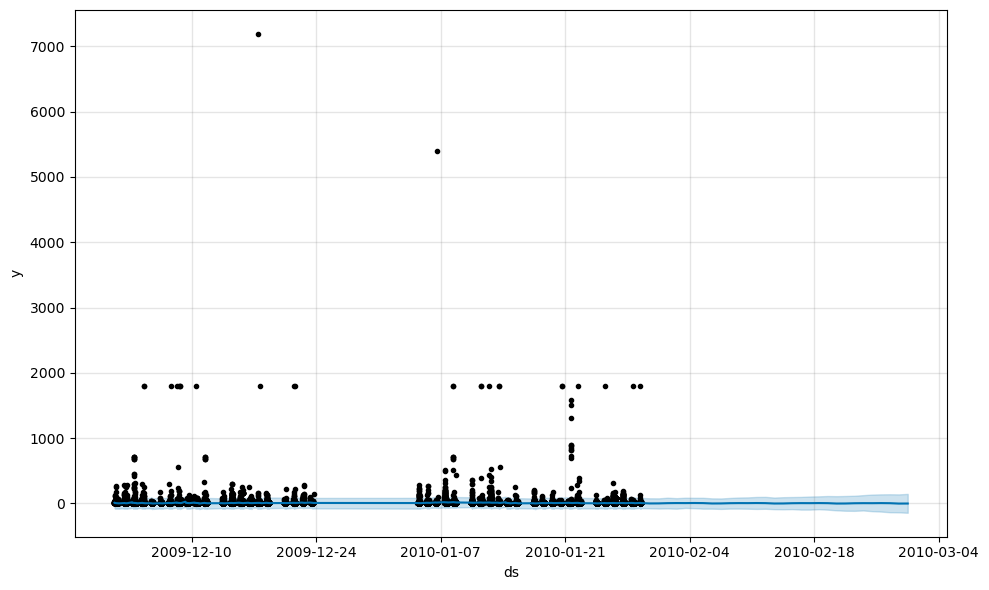

In [8]:
fig = model.plot(forecast)
plt.show()

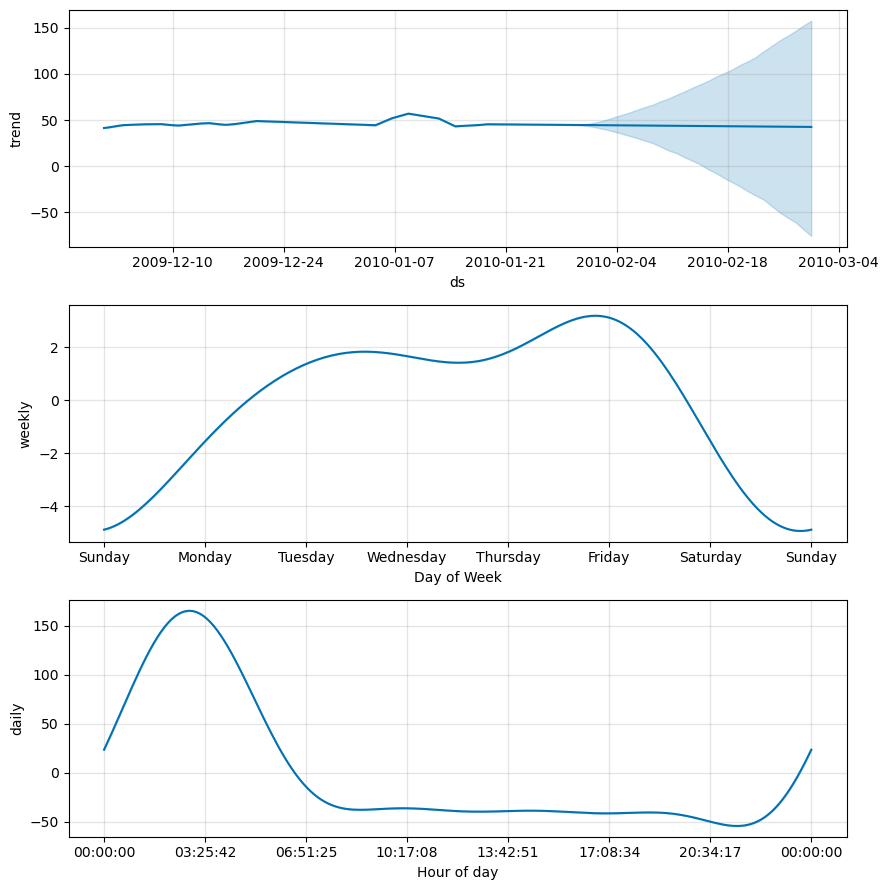

In [9]:
fig2 = model.plot_components(forecast)
plt.show()

In [11]:
compare = df.merge(forecast[['ds', 'yhat']], on='ds', how='inner')

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(compare['y'], compare['yhat'])
rmse = np.sqrt(mean_squared_error(compare['y'], compare['yhat']))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 8.785246992262955
RMSE: 62.162409741157155


In [13]:
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].to_csv(
    r"C:\Users\good2\Desktop\forecast.csv",
    index=False
)